In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from math import isnan

/home/benjamin/anaconda3/lib/python3.11/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
"""

Estimate the change in basal flow.

This could be used directly *but* there are variations between measurements in the maximum and minimum values
estimated by eliminating and flooding with calcium. This is the function

basal_r = (basal - rmin) / (rmax-rmin)

it expresses the basal flow as a float between 0 and 1, representing between completely closed (min) and fully open (max)

Start by loading the raw gribble ratiometric data

This is spread across multiple sheets

"""

'\n\nEstimate the change in basal flow.\n\nThis could be used directly *but* there are variations between measurements in the maximum and minimum values\nestimated by eliminating and flooding with calcium. This is the function\n\nbasal_r = (basal - rmin) / (rmax-rmin)\n\nit expresses the basal flow as a float between 0 and 1, representing between completely closed (min) and fully open (max)\n\nStart by loading the raw gribble ratiometric data\n\nThis is spread across multiple sheets\n\n'

In [3]:
def find_header_row(filepath, sheet_name, keyword, fallback="Date"):
    """Find row containing header based on keyword"""
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    
    for idx, row in df.iterrows():
        # Check if any cell in row contains the keyword
        if row.astype(str).str.contains(keyword, case=False).any():
            return (True,idx)
    
    # Some sheets lack a header line. In this case the data follows the date line
    for idx, row in df.iterrows():
        # Check if any cell in row contains the keyword
        if row.astype(str).str.contains(fallback, case=False).any():
            return (False,idx)
    print("Header Error:",filepath, sheet_name, keyword, fallback)
    return None

def find_end_row(filepath, sheet_name):
    """Find row ending main data based on NaN row after ionomycin introduction"""
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    absolute_end = None
    for idx, row in df.iterrows():
        # Check if any cell in row contains a non-NaN
        if row.isnull().all():
            #print(idx, df.iloc[idx+1][0])
            #if str(df.iloc[idx+1][0]) == "basal":
            #    return idx
            if isnan(df.iloc[idx+1][1]):
                absolute_end = idx
                break
    if absolute_end == None:
        print("End Error:",filepath, sheet_name)
        raise
    
    #some traces show strong variation +/- 25% at the end of the experiment.
    #this can break the downstream analysis so test for this and adjust the end returned
    
    #Crude test; if the last 10 entries in the first ratiometric column changes exceed the
    # threshold return it without the last 10
    
    threshold = 0.2
    
    end_df = df.iloc[absolute_end-10:absolute_end][df.columns[3]]
    
    largest_d = 0
    
    for i,v in enumerate(end_df[:-1]):
        d = abs(1-v/end_df.iloc[i+1])
        if d > largest_d:
            largest_d = d
    if largest_d > threshold:
        print("Warning- sharp changes at end of file")
        return absolute_end-10
    else:
        return absolute_end
def read_excel_raw(filename, sheet_name):
    #get header row
    headerExists, header_row = find_header_row(filename, sheet_name, "Time")
    #get end row
    end_row = find_end_row("./FG combined data Feb 2025.xlsx",sheet_name=sheet_name)
    #read excel based on probe information
    df = pd.read_excel(filename,sheet_name=sheet_name,nrows=end_row-header_row,header=header_row, )
    
    
    return(df)

def trace_sheet(filepath, sheet_name):
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    row = df.iloc[0]
    pound = row.astype(str).str.contains("#", case=False).any()
    file = row.astype(str).str.contains("File", case=False).any()
    return(pound or file)

def remove_flu_columns(df):
    """keep every third column. This should correspond to the ratio or the time"""
    cols = df.columns
    ignore = []
    for i,c in enumerate(cols):
        if i%3 != 0:
            ignore.append(c)
    df = df.drop(columns=ignore)
    return(df)

def remove_non_ratio_elements_series(df):
    """Like above, works on rows"""
    
    #The test if the headers are present
    if  "Time" in df.index[0]:
        ignore = []
        for c in df.index:
            if c.split()[-1] != "R1":
                ignore.append(c)
    elif "Date" in df.index[0]:
        #headers are not present. Return every third element, except index 0
        ignore = []
        for i,c in enumerate(df.index):
            if i == 0 or i%3 != 0:
                ignore.append(c)
    else:
        raise
    df = df.drop(ignore)
    return(df)

def extract_raw(filename):
    sheet_names = pd.ExcelFile(filename).sheet_names
    traces = {}
    for sheet_name in sheet_names:
        if trace_sheet(filename,sheet_name):
            print(sheet_name)
            traces[sheet_name] = read_excel_raw(filename,sheet_name) 
    return(traces)

def compile_genotype_series(traces):
    """Returns a set of traces derived from sheets in single dataframes per genotype"""
    
    trace_compilation = {}
    
    for traceID in traces.keys():
        genotype = traceID.split()[0]
        if genotype in trace_compilation.keys():
            trace_compilation[genotype] = pd.concat([trace_compilation[genotype],traces[traceID]])
        else:
            trace_compilation[genotype] = traces[traceID]
            
    return trace_compilation

In [4]:

def read_excel_processed(filepath,sheet_name): 
    df = pd.read_excel(filepath, sheet_name=sheet_name , index_col=0)    
    df = df.loc[["Rmin","Rmax","R basal", "R CA"]]
    return df

def confirm_processed(filepath, sheet_name):
    df = pd.read_excel(filepath, sheet_name=sheet_name,index_col=0, header=None)
    if "Rmax" in df.index:
        return True
    else:
        return False

def extract_processed(filename):
    sheet_names = pd.ExcelFile(filename).sheet_names
    traces = {}
    for sheet_name in sheet_names:
        if not trace_sheet(filename,sheet_name) and confirm_processed(filename,sheet_name):
            print(sheet_name)
            traces[sheet_name] = read_excel_processed(filename,sheet_name) 
    return(traces)

def trim_after_empty_column(df):
    """
    Remove the first fully-empty OR fully-zero column
    and all columns to its right.
    """
    # Normalize empty strings / whitespace to NA
    cleaned = df.replace(r'^\s*$', pd.NA, regex=True)

    # Fully empty columns
    empty_cols = cleaned.isna().all()

    # Fully zero columns (ignoring NaNs)
    zero_cols = cleaned.apply(
        lambda col: pd.to_numeric(col, errors='coerce').fillna(0).eq(0).all()
    )

    # Combine both conditions
    cutoff_mask = empty_cols | zero_cols

    if not cutoff_mask.any():
        return df.copy()

    # First column that is empty OR zero
    cutoff_col = cutoff_mask.idxmax()
    cutoff_idx = df.columns.get_loc(cutoff_col)

    return df.iloc[:, :cutoff_idx]

def calculate_relative_basal_processed(df, scale = True):
    df = trim_after_empty_column(df)

    basal = df.loc["R basal"]
    if not scale:
        return basal
    rmin = df.loc["Rmin"]
    rmax = df.loc["Rmax"]
    result = (basal-rmin)/(rmax-rmin)
    """
    print(basal.isna().any())
    print(rmin.isna().any())
    print(rmax.isna().any())
    print(result.isna().any())
    """
    return result

def calculate_relative_CA_response_processed(df, scale = True):
    df = trim_after_empty_column(df)
    ca_response = df.loc["R CA"]
    if not scale:
        return ca_response
    rmin = df.loc["Rmin"]
    rmax = df.loc["Rmax"]
    result = (ca_response-rmin)/(rmax-rmin)
    """
    print(basal.isna().any())
    print(rmin.isna().any())
    print(rmax.isna().any())
    print(result.isna().any())
    """
    return result

In [5]:
display(read_excel_processed("./FG combined data Feb 2025.xlsx",sheet_name="Empty CK0807-d4") )

display(read_excel_processed("./FG combined data Feb 2025.xlsx",sheet_name="Empty CK0807-d6") )

display(read_excel_processed("./FG combined data Feb 2025.xlsx",sheet_name="Empty CK1507-d7") )

exampleProcessed = read_excel_processed("./FG combined data Feb 2025.xlsx",sheet_name="Empty CK0807-d4")

,R2 R1,R3 R1,R4 R1,R5 R1,R6 R1,R7 R1,R8 R1,R9 R1,R10 R1,R11 R1,...,R21 R1,R22 R1,R23 R1,R24 R1,R25 R1,R26 R1,R27,R28 R1,Unnamed: 28,average
Rmin,0.971,0.963,0.949,0.937,0.96,0.971,0.955,0.953000,0.967000,0.975000,...,0.966000,0.969000,0.972000,0.975000,0.950000,0.972000,0.962428,0.955000,NaN,0.959794
Rmax,1.158,1.176,1.246,1.238,1.234,1.18,1.24,1.262000,1.201000,1.152000,...,1.222000,1.190000,1.184000,1.146000,1.214000,1.157000,1.190758,1.256000,NaN,1.217954
R basal,1.060444,1.087611,1.113889,1.1145,1.108444,1.066167,1.088278,1.130278,1.149056,1.054167,...,1.090722,1.085333,1.073222,1.037944,1.091556,1.053389,1.078820,1.099556,NaN,1.099777
R CA,1.062,1.089,1.117,1.112,1.109,1.066,1.088,1.130000,1.150000,1.055000,...,1.091000,1.083000,1.070000,1.039000,1.092000,1.053000,1.079575,1.097000,NaN,1.099984


,R2 R1,R3 R1,R4 R1,R5 R1,R6 R1,R7 R1,R8 R1,R9 R1,R10 R1,R11 R1,...,R14 R1,R15 R1,R16 R1,R17 R1,R18 R1,R19 R1,R20 R1,R21 R1,Unnamed: 21,average
Rmin,0.962,0.965,0.971,0.961,0.961,0.97,0.967,0.961000,0.961000,0.958000,...,0.950000,0.955000,0.959000,0.958000,0.944000,0.968000,0.976000,0.962000,NaN,0.960250
Rmax,1.273,1.261,1.181,1.202,1.297,1.371,1.224,1.245000,1.242000,1.250000,...,1.257000,1.303000,1.261000,1.295000,1.283000,1.232000,1.239000,1.227000,NaN,1.255600
R basal,1.080263,1.118158,1.065316,1.048789,1.085632,1.215421,1.071211,1.072211,1.064368,1.078526,...,1.090842,1.069947,1.075947,1.072526,1.044947,1.069158,1.030053,1.123316,NaN,1.079113
R CA,1.079,1.118,1.066,1.049,1.087,1.206,1.071,1.071000,1.064000,1.077000,...,1.088000,1.068000,1.075000,1.081000,1.054000,1.069000,1.029000,1.119000,NaN,1.078800


,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
Rmin,0.994,0.991000,0.997,0.99,0.996,0.999,0.994,0.995000,0.990000,0.990000,...,0.989,0.99000,0.996000,0.982000,0.99100,0.991000,0.977000,0.996000,0.985000,1.00600
Rmax,1.213,1.135000,1.144,1.21,1.141,1.111,1.11,1.134000,1.127000,1.114000,...,1.150,1.12800,1.151000,1.115000,1.15400,1.134000,1.176000,1.159000,1.205000,1.16700
R basal,0.988,0.990313,0.99825,0.98725,0.99475,0.997687,0.994125,0.992125,0.992625,0.991813,...,0.989,0.98875,0.993812,0.981062,0.99125,0.987625,0.976313,0.997563,0.980937,1.00325
R CA,0.993,0.995000,1.003,0.993,0.997,1.001,0.998,0.997000,0.998000,0.996000,...,0.994,0.99300,0.997000,0.984000,0.99400,0.994000,0.980000,1.003000,0.982000,1.00600


In [6]:
confirm_processed("./FG combined data Feb 2025.xlsx", "L290P CK2006-d7")

True

In [7]:
example = pd.read_excel("./FG combined data Feb 2025.xlsx", sheet_name="L290P CK2006-d7", header=None, index_col=0)

In [8]:
example.loc[["Rmin","Rmax","R basal", "R CA"]]

,1,2,3,4,5,6,7,8,9,10,...,24,25,26,27,28,29,30,31,32,33
0,,,,,,,,,,,,,,,,,,,,,
Rmin,0.988,0.992,0.985,0.985,0.997,0.988,0.993,0.998,0.989,0.987,...,0.988,0.982,0.991,0.988,0.988,0.994,0.988,NaN,0.988724,NaN
Rmax,1.1,1.128,1.15,1.156,1.135,1.118,1.112,1.106,1.147,1.093,...,1.117,1.131,1.134,1.142,1.149,1.128,1.126,NaN,1.123241,NaN
R basal,1.013529,1.027176,1.018941,1.028647,1.028765,1.021353,1.030294,1.022118,1.023824,1.017353,...,1.024824,1.028,1.035529,1.028882,1.038176,1.023824,1.036412,NaN,1.023876,NaN
R CA,1.016,1.033,1.023,1.043,1.033,1.026,1.033,1.026,1.027,1.023,...,1.027,1.03,1.038,1.032,1.04,1.026,1.04,NaN,1.028103,NaN


In [9]:
def plotTrace(traces,name):
    w = remove_flu_columns(traces[name])

    w.plot(x=w.columns[0])
    plt.show()

In [10]:
def getTreatments(df):
    fstCol = df.columns[1]
    try:
        result = df[df[fstCol].apply(lambda x: isinstance(x, str))][["Time (min)",fstCol]]
    except:
        guess = df.columns[0]
        result = df[df[fstCol].apply(lambda x: isinstance(x, str))][[guess,fstCol]]
    return(result)

def getRatioColumns(df):
    # ratio column names have R1 as the last word
    matching_cols = [col for col in df.columns if col.split()[-1] == 'R1' or col.split()[0] == 'Time']
    return(df[matching_cols])

In [11]:
def get_CA_row(df):
    for idx, row in df.iterrows():
        # Check if any cell in row contains the keyword
        if row.astype(str).str.contains("CA", case=False).any():
            return idx
    return None

def extract_basal(df):
    ca_row = get_CA_row(df)
    # Follow Gribble spreadsheet routine and only average the last 20 measurements before the CA addition
    df = df.iloc[ca_row-20:ca_row]
    result = df.mean()
    return result

def extract_ca_response(df):
    ca_row = get_CA_row(df)
    end_row = None
    for item in getTreatments(df).index:
        if item>ca_row:
            end_row = item
            break
    # Follow Gribble spreadsheet routine and max from the CA addition to either the next treatment or end of file
    if end_row == None:
        print("Warning- no further treatments after CA")
        end_row = df.index[-1]
    df = df.iloc[ca_row+1:end_row]
    result = df.max()
    return result

def remove_nonfloats(df):
    df = df[~df.applymap(lambda x: isinstance(x, str)).any(axis=1)]
    return(df)

def calculate_relative_basal(df, scale = True):
    basal = extract_basal(df)
    if not scale:
        return basal
    df = remove_nonfloats(df)
    rmin = df.min()
    rmax = df.max() # should consider filtering for problems at the end of some traces
    result = (basal-rmin)/(rmax-rmin)
    """
    print(basal.isna().any())
    print(rmin.isna().any())
    print(rmax.isna().any())
    print(result.isna().any())
    """
    return result

def calculate_relative_CA_response(df, scale = True):
    ca_response = extract_ca_response(df)
    if not scale:
        return ca_response
    df = remove_nonfloats(df)
    rmin = df.min()
    rmax = df.max() # should consider filtering for problems at the end of some traces
    result = (ca_response-rmin)/(rmax-rmin)
    """
    print(basal.isna().any())
    print(rmin.isna().any())
    print(rmax.isna().any())
    print(result.isna().any())
    """
    return result

In [12]:
def heatmap(data, title='Relative basal heatmap', cbar_title='Relative response', vmin=0, vmax=1):
    fig3, ax3 = plt.subplots(figsize=(10, 6))

    groups = list(data.columns)
    max_n = data.count().max()
    data_matrix = np.full((len(groups), max_n), np.nan)

    for i, group in enumerate(groups):
        values = data[group]
        data_matrix[i, :len(values)] = values

    im = ax3.imshow(data_matrix, aspect='auto', cmap='YlOrRd',
                    interpolation='nearest', vmin=vmin, vmax=vmax)

    ax3.set_yticks(np.arange(len(groups)))
    ax3.set_yticklabels(groups, fontsize=11, fontweight='bold')
    ax3.set_xlabel('Replicate', fontsize=12)
    ax3.set_title(title, fontsize=14, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax3)
    cbar.set_label(cbar_title, rotation=270, labelpad=20, fontsize=11)

    plt.tight_layout()
    
def barChart(data, title="Relative basal", plotRaw=True):
    fig2, axes = plt.subplots(figsize=(12, 5))

    #for idx, metric in enumerate(['amplitude', 'auc']):
    #    ax = axes[idx]

    ax = axes
    colors = plt.cm.Set2(np.linspace(0, 1, len(data)))

    groups = list(data.columns)


    means = [np.mean(data[g]) for g in groups]
    sems = [stats.sem(data[g].to_numpy(dtype=float),nan_policy='omit') for g in groups]

    x_pos = np.arange(len(groups))
    bars = ax.bar(x_pos, means, yerr=sems, capsize=5,
                 color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    #ax.boxplot([data[col].dropna() for col in data.columns])

    # Individual points
    for i, group in enumerate(groups):
        values = data[group]
        x_jitter = np.random.normal(i, 0.05, size=len(values))

        if plotRaw:
            ax.scatter(x_jitter, values, color='black', alpha=0.5, s=30, zorder=3)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, rotation=45, ha='right')
    ax.set_ylabel(title.title(), fontsize=11)
    ax.set_title(f'{title.title()}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add sample sizes
    for i, group in enumerate(groups):
        n = data[group].count()
        ax.text(i, ax.get_ylim()[0], f'n={n}', ha='center',
               va='top', fontsize=8, style='italic')

    plt.tight_layout()

def boxplot(data, title="Relative basal", plotRaw=True):
    fig2, axes = plt.subplots(figsize=(12, 5))
    ax = axes
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(data)))
    groups = list(data.columns)
    x_pos = np.arange(len(groups))
    
    # BOXPLOT instead of bar chart
    box_data = [data[col].dropna() for col in groups]
    bp = ax.boxplot(box_data, positions=x_pos, widths=0.6,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(color='black', linewidth=1),
                    capprops=dict(color='black', linewidth=1),
                    boxprops=dict(linewidth=1.5))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
    
    # Individual points (overlaid on boxes)
    if plotRaw:
        for i, group in enumerate(groups):
            values = data[group].dropna()
            x_jitter = np.random.normal(i, 0.05, size=len(values))
            ax.scatter(x_jitter, values, color='black', alpha=0.5, s=30, zorder=3)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, rotation=45, ha='right')
    ax.set_ylabel(title.title(), fontsize=11)
    ax.set_title(f'{title.title()}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add sample sizes
    for i, group in enumerate(groups):
        n = data[group].count()
        ax.text(i, ax.get_ylim()[0], f'n={n}', ha='center',
               va='top', fontsize=8, style='italic')
    
    plt.tight_layout()    
    
def statistical_comparison(data):
    groups = list(data.columns)
    datap = [data[g].dropna() for g in groups]

    # ANOVA
    f_stat, p_val = stats.f_oneway(*datap)

    # Effect size
    grand_mean = np.mean(np.concatenate(datap))
    ss_between = sum(len(d) * (np.mean(d) - grand_mean)**2 for d in datap)
    ss_total = sum(np.sum((d - grand_mean)**2) for d in datap)
    eta_squared = ss_between / ss_total

    results = {
        'metric': "delta",
        'F_statistic': f_stat,
        'p_value': p_val,
        'eta_squared': eta_squared,
        'significant': p_val < 0.05
    }

    # Post-hoc: compare each to WT
    if p_val < 0.05 and 'WT' in groups:
        wt_idx = groups.index('WT')
        results['posthoc'] = {}

        for i, group in enumerate(groups):
            if i != wt_idx:
                t_stat, p = stats.ttest_ind(datap[wt_idx].to_numpy(dtype=float), datap[i].to_numpy(dtype=float))
                mean_diff = np.mean(datap[wt_idx]) - np.mean(datap[i])
                pooled_std = np.sqrt((np.var(datap[wt_idx]) + np.var(datap[i])) / 2)
                cohens_d = mean_diff / pooled_std

                results['posthoc'][f'WT vs {group}'] = {
                    'p_value': p,
                    'mean_diff': mean_diff,
                    'cohens_d': cohens_d
                }
    return results

In [13]:
def plot_boxplot_basal_response(df_basal, df_response, figsize=(12, 6)):
    """
    Box plot version of basal and response comparison
    """
    genotypes = df_basal.columns.tolist()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare data
    basal_data = [df_basal[col].dropna() for col in genotypes]
    response_data = [df_response[col].dropna() for col in genotypes]
    
    # Positions for side-by-side boxes
    positions_basal = np.arange(len(genotypes)) * 3 - 0.6
    positions_response = np.arange(len(genotypes)) * 3 + 0.6
    
    # Create box plots
    bp1 = ax.boxplot(basal_data, positions=positions_basal, widths=0.8,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='steelblue', alpha=0.7),
                     medianprops=dict(color='darkblue', linewidth=2),
                     whiskerprops=dict(color='darkblue'),
                     capprops=dict(color='darkblue'))
    
    bp2 = ax.boxplot(response_data, positions=positions_response, widths=0.8,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='coral', alpha=0.7),
                     medianprops=dict(color='darkred', linewidth=2),
                     whiskerprops=dict(color='darkred'),
                     capprops=dict(color='darkred'))
    
    # Add individual points (like in bar chart)
    for i, genotype in enumerate(genotypes):
        # Basal points
        basal_values = df_basal[genotype].dropna()
        x_basal = np.random.normal(positions_basal[i], 0.08, size=len(basal_values))
        ax.scatter(x_basal, basal_values, color='darkblue', 
                  alpha=0.6, s=40, zorder=3, edgecolors='white', linewidth=0.5)
        
        # Response points
        response_values = df_response[genotype].dropna()
        x_response = np.random.normal(positions_response[i], 0.08, size=len(response_values))
        ax.scatter(x_response, response_values, color='darkred',
                  alpha=0.6, s=40, zorder=3, edgecolors='white', linewidth=0.5)
    
    # Formatting
    ax.set_xlabel('Genotype', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Calcium Ratio', fontsize=12, fontweight='bold')
    ax.set_title('Basal and Agonist-Evoked Calcium Responses', 
                fontsize=14, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(np.arange(len(genotypes)) * 3)
    ax.set_xticklabels(genotypes, rotation=45, ha='right')
    
    # Legend
    ax.legend([bp1["boxes"][0], bp2["boxes"][0]], 
             ['Basal', 'CA Response'], loc='best', fontsize=11)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add sample sizes
    for i, genotype in enumerate(genotypes):
        n_basal = df_basal[genotype].notna().sum()
        n_response = df_response[genotype].notna().sum()
        ax.text(i * 3, ax.get_ylim()[0], f'n={n_basal}/{n_response}',
               ha='center', va='top', fontsize=8, style='italic')
    
    plt.tight_layout()
    return fig, ax

def plot_basal_and_response(df_basal, df_response, figsize=(12, 6)):
    """
    Plot basal and response as grouped bar chart with individual points
    
    Parameters:
    -----------
    df_basal : DataFrame
        Basal values, each column is a genotype
    df_response : DataFrame
        Response values, each column is a genotype
    """
    genotypes = df_basal.columns.tolist()
    
    # Calculate statistics
    basal_means = df_basal.mean()
    basal_sems = df_basal.sem()
    response_means = df_response.mean()
    response_sems = df_response.sem()
    
    # Setup plot
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(genotypes))
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, basal_means, width, 
                   yerr=basal_sems, capsize=5,
                   label='Basal', color='steelblue', alpha=0.7,
                   edgecolor='black', linewidth=1.5)
    
    bars2 = ax.bar(x + width/2, response_means, width,
                   yerr=response_sems, capsize=5,
                   label='CA Response', color='coral', alpha=0.7,
                   edgecolor='black', linewidth=1.5)
    
    # Add individual points
    for i, genotype in enumerate(genotypes):
        # Basal points
        basal_values = df_basal[genotype].dropna()
        x_basal = np.random.normal(i - width/2, 0.04, size=len(basal_values))
        ax.scatter(x_basal, basal_values, color='darkblue', 
                  alpha=0.6, s=40, zorder=3, edgecolors='white', linewidth=0.5)
        
        # Response points
        response_values = df_response[genotype].dropna()
        x_response = np.random.normal(i + width/2, 0.04, size=len(response_values))
        ax.scatter(x_response, response_values, color='darkred',
                  alpha=0.6, s=40, zorder=3, edgecolors='white', linewidth=0.5)
    
        
    # Formatting
    ax.set_xlabel('Genotype', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Calcium Ratio', fontsize=12, fontweight='bold')
    ax.set_title('Basal and Agonist-Evoked Calcium Responses', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(genotypes, rotation=45, ha='right')
    ax.legend(loc='best', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add sample sizes
    for i, genotype in enumerate(genotypes):
        n_basal = df_basal[genotype].notna().sum()
        n_response = df_response[genotype].notna().sum()
        ax.text(i, ax.get_ylim()[0], f'n={n_basal}/{n_response}',
               ha='center', va='top', fontsize=8, style='italic')
    
    plt.tight_layout()
    return fig, ax

In [14]:
print(find_header_row("./FG combined data Feb 2025.xlsx", "K186N 2706-d4", "Time"))
print(find_end_row("./FG combined data Feb 2025.xlsx",sheet_name="K186N 2706-d4"))
print(find_end_row("./FG combined data Feb 2025.xlsx",sheet_name="WT 1506-d3"))

read_excel_raw("./FG combined data Feb 2025.xlsx",sheet_name="K186N 2706-d4") 
print(trace_sheet("./FG combined data Feb 2025.xlsx",sheet_name="K186N 2706-d4"))
print(trace_sheet("./FG combined data Feb 2025.xlsx",sheet_name="H1018R CK1107-d5"))
print(trace_sheet("./FG combined data Feb 2025.xlsx",sheet_name="basal calibrated Ca conc"))
print(trace_sheet("./FG combined data Feb 2025.xlsx",sheet_name="WT 2206-d5"))


(True, 23)
1091
Warning- sharp changes at end of file
1141
True
False
False
True


In [15]:
wt1506_d3 = pd.read_excel("./FG combined data Feb 2025.xlsx",sheet_name="WT 1506-d3",nrows=1133,skiprows=17)#,usecols="A:M")
wt1506_d4 = pd.read_excel("./FG combined data Feb 2025.xlsx",sheet_name="WT 1506-d4",nrows=601,skiprows=13)#,usecols="A:M")
k186N_2706_d4 = pd.read_excel("./FG combined data Feb 2025.xlsx",sheet_name="K186N 2706-d4",nrows=1069,skiprows=23)
k186N_2706_d4

,Time (min),R1 W1 Avg,R1 W2 Avg,R1 R1,R2 W1 Avg,R2 W2 Avg,R2 R1,R3 W1 Avg,R3 W2 Avg,R3 R1,...,R18 R1,R19 W1 Avg,R19 W2 Avg,R19 R1,R20 W1 Avg,R20 W2 Avg,R20 R1,R21 W1 Avg,R21 W2 Avg,R21 R1
0,12.282,220.566,215.793,1.023000,222.083,214.745,1.034000,225.077,223.180,1.011000,...,1.04900,236.087,222.824,1.061000,223.292,209.271,1.067000,216.743,210.443,1.030000
1,0.000,Clock reset to 0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.014,220.487,216.173,1.020000,221.406,215.278,1.029000,225.071,223.492,1.010000,...,1.04900,236.791,223.227,1.062000,222.950,209.150,1.066000,216.194,211.030,1.025000
3,0.048,220.898,216.383,1.021000,222.035,215.397,1.031000,225.272,223.585,1.010000,...,1.04200,236.460,223.898,1.058000,223.401,209.694,1.066000,216.117,210.613,1.027000
4,0.081,220.592,216.276,1.020000,221.981,215.476,1.031000,225.202,223.488,1.011000,...,1.04800,236.661,223.579,1.060000,223.746,209.428,1.069000,216.557,210.290,1.030000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064,35.281,238.851,204.080,1.171000,234.719,204.278,1.149000,242.695,208.081,1.168000,...,1.13500,241.296,213.128,1.132000,229.433,203.840,1.126000,221.786,203.440,1.091000
1065,35.314,239.602,204.195,1.174000,235.261,203.881,1.154000,242.924,207.980,1.170000,...,1.13800,242.257,213.138,1.137000,229.644,204.024,1.126000,222.041,203.467,1.092000
1066,35.348,239.276,204.169,1.172000,235.426,203.988,1.154000,242.631,207.851,1.169000,...,1.13600,240.988,212.917,1.132000,229.330,203.962,1.125000,222.281,203.318,1.094000
1067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
#k186N_2706_d4.iloc[get_CA_row(k186N_2706_d4)-20:get_CA_row(k186N_2706_d4)].mean() #wt1506_d4
b = extract_basal(k186N_2706_d4)
df = remove_nonfloats(k186N_2706_d4)
rmin = df.min()
rmax = df.max()
(b-rmin)/(rmax-rmin)

Time (min)     0.05332
R1 W1 Avg     0.215324
R1 W2 Avg     0.723311
R1 R1         0.204082
R2 W1 Avg      0.30567
                ...   
R20 W2 Avg    0.818275
R20 R1        0.126712
R21 W1 Avg    0.329056
R21 W2 Avg    0.819373
R21 R1        0.223077
Length: 64, dtype: object

In [17]:
#x = calculate_relative_basal(traces["WT 1506-d3"])

In [18]:
traces = extract_raw("./FG combined data Feb 2025.xlsx")

WT 1506-d3
Warning- sharp changes at end of file
WT 1506-d4
WT 2006-d2
WT 2006-d3
WT 2006-d9
WT 2206-d2
WT 2206-d5
WT 2706-d2
K186N 2706-d4
K186N 2706-d5
K186N 2706-d6
L290P 2206-d1
L566R 2706-d3
L566R 2706-d7
L566R 0407-d4
L776S 0407-d7
N855S 1706-d1
N855S 1706-d2
N855S 1706-d4
S443C 1706-d7
S443C 1706-d8


In [19]:
processed = extract_processed("./FG combined data Feb 2025.xlsx")

Empty CK0807-d4
Empty CK0807-d6
Empty CK1507-d7
WT CK2906-d2
WT CK0407-d3
WT CK0707-d1
E179K CK0707-d2
E179K CK0707-d3
E179K CK0707-d5
H1018R CK1107-d2
H1018R CK1107-d5
H1018R CK1107-d6
K186N CK1207-d3
K186N CK1207-d4
K186N CK1207-d5
K390N CK1107-d3
K390N CK1207-d1
K390N CK1207-d2
L290P CK2006-d5
L290P CK2006-d7
L290P CK2006-d8
L290P CK2206-d3
L290P CK2206-d4
L290P CK2206-d6
L566R CK2206-d7
L566R CK2706-d1
L566R CK0407-d5
L566R CK0407-d6
L776S CK2906-d3
L776S CK0407-d1
L776S CK0407-d2
N855S CK2906-d1
Q204K CK0707-d4
Q204K CK0707-d6
Q204K CK0707-d7
S443C CK1706-d5
S443C CK1706-d6
S443C CK0807-d1
S443C CK0807-d2
S443C CK0807-d5


In [20]:
basal = {}
ca = {}

print("From traces")

for key in traces.keys():
    print(key)
    basal[key] = calculate_relative_basal(traces[key])
    ca[key] = calculate_relative_CA_response(traces[key]) 
    

    

From traces
WT 1506-d3
WT 1506-d4
WT 2006-d2
WT 2006-d3
WT 2006-d9
WT 2206-d2
Warning- no further treatments after CA
WT 2206-d5
WT 2706-d2
K186N 2706-d4
K186N 2706-d5
K186N 2706-d6
L290P 2206-d1
L566R 2706-d3
L566R 2706-d7
L566R 0407-d4
L776S 0407-d7
N855S 1706-d1
N855S 1706-d2
N855S 1706-d4
S443C 1706-d7
S443C 1706-d8


In [21]:
basalc = {}
for key in basal.keys():
    basalc[key] = remove_non_ratio_elements_series(basal[key])




In [22]:
ca_response = {}
for key in ca.keys():
    ca_response[key] = remove_non_ratio_elements_series(ca[key])

    
#ca_response_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in ca_response_g.items()})
#ca_response_df

In [23]:
print("From processed data")
for key in processed.keys():
    print(key)
    basalc[key] = calculate_relative_basal_processed(processed[key])
    ca_response[key] = calculate_relative_CA_response_processed(processed[key])

#ca_response_g = compile_genotype_series(ca_response)
    
    
basal_df_individual = pd.DataFrame({k: v.reset_index(drop=True) for k, v in basalc.items()})
ca_response_df_individual = pd.DataFrame({k: v.reset_index(drop=True) for k, v in ca_response.items()})


From processed data
Empty CK0807-d4
Empty CK0807-d6
Empty CK1507-d7
WT CK2906-d2
WT CK0407-d3
WT CK0707-d1
E179K CK0707-d2
E179K CK0707-d3
E179K CK0707-d5
H1018R CK1107-d2
H1018R CK1107-d5
H1018R CK1107-d6
K186N CK1207-d3
K186N CK1207-d4
K186N CK1207-d5
K390N CK1107-d3
K390N CK1207-d1
K390N CK1207-d2
L290P CK2006-d5
L290P CK2006-d7
L290P CK2006-d8
L290P CK2206-d3
L290P CK2206-d4
L290P CK2206-d6
L566R CK2206-d7
L566R CK2706-d1
L566R CK0407-d5
L566R CK0407-d6
L776S CK2906-d3
L776S CK0407-d1
L776S CK0407-d2
N855S CK2906-d1
Q204K CK0707-d4
Q204K CK0707-d6
Q204K CK0707-d7
S443C CK1706-d5
S443C CK1706-d6
S443C CK0807-d1
S443C CK0807-d2
S443C CK0807-d5


In [24]:
basalc

{'WT 1506-d3': R1 R1      0.02875
 R2 R1     0.036792
 R3 R1      0.02875
 R4 R1     0.099157
 R5 R1      0.02663
 R6 R1     0.040336
 R7 R1     0.057895
 R8 R1      0.05894
 R9 R1     0.068072
 R10 R1    0.109917
 R11 R1    0.064008
 R12 R1    0.050472
 R13 R1    0.098585
 R14 R1    0.105828
 R15 R1    0.103182
 dtype: object,
 'WT 1506-d4': R1 R1     0.055628
 R2 R1     0.041667
 R3 R1     0.048222
 R4 R1     0.034764
 R5 R1     0.028673
 R6 R1     0.048649
 R7 R1     0.040314
 R8 R1         0.04
 R9 R1     0.053171
 R10 R1    0.048684
 R11 R1    0.110904
 dtype: object,
 'WT 2006-d2': R1 R1       0.0416
 R2 R1      0.02997
 R3 R1     0.011145
 R4 R1     0.138561
 R5 R1     0.039274
 R6 R1     0.029167
 R7 R1     0.088185
 R8 R1     0.009802
 R9 R1     0.053762
 R10 R1    0.012562
 R11 R1    0.058796
 R12 R1    0.052128
 R13 R1    0.079074
 R14 R1    0.067944
 R15 R1    0.016849
 dtype: object,
 'WT 2006-d3': R1 R1     0.078431
 R2 R1     0.061709
 R3 R1     0.078859
 R4 R1     0.139

# Experiment level analysis
(check for batch variation)

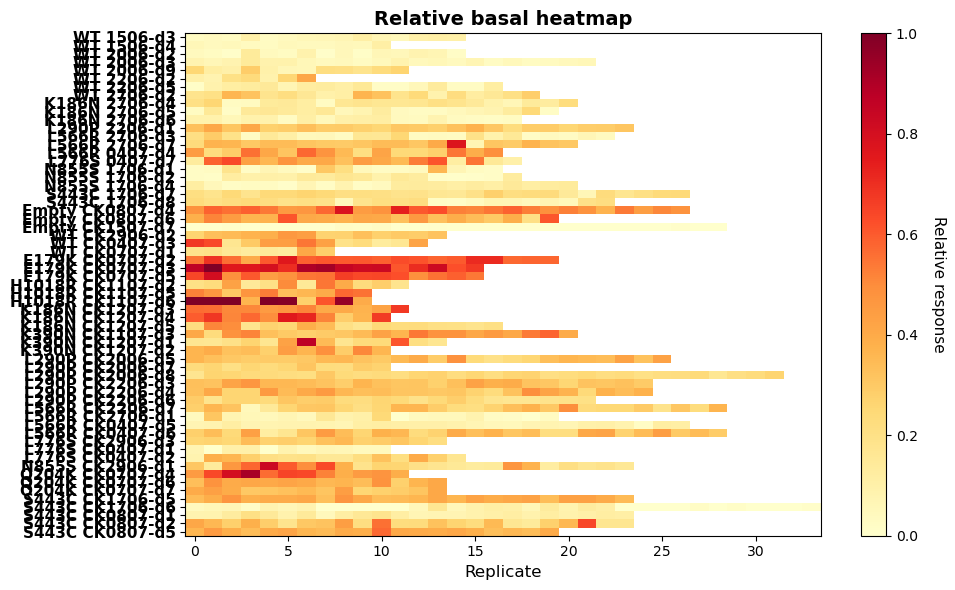

In [25]:
heatmap(basal_df_individual)

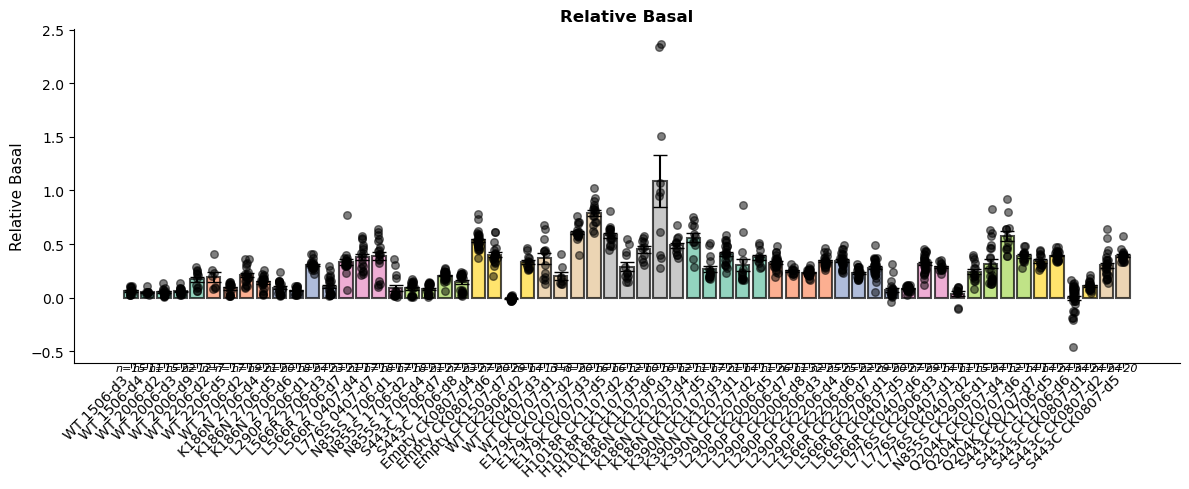

In [26]:
barChart(basal_df_individual)

## CA responses

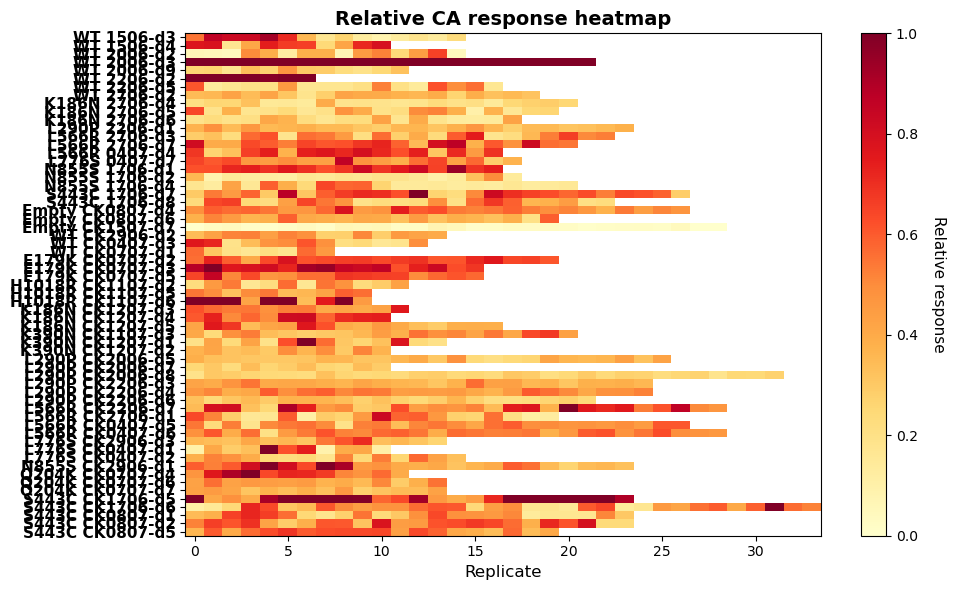

In [27]:
heatmap(ca_response_df_individual,"Relative CA response heatmap","Relative response")


In [28]:
getTreatments(traces["WT 2006-d3"])

,Time (min),R1 W1 Avg
1,0.000,Clock reset to 0.0
94,3.064,CA (100uM)
203,6.663,Basal
364,11.983,CA (100uM)


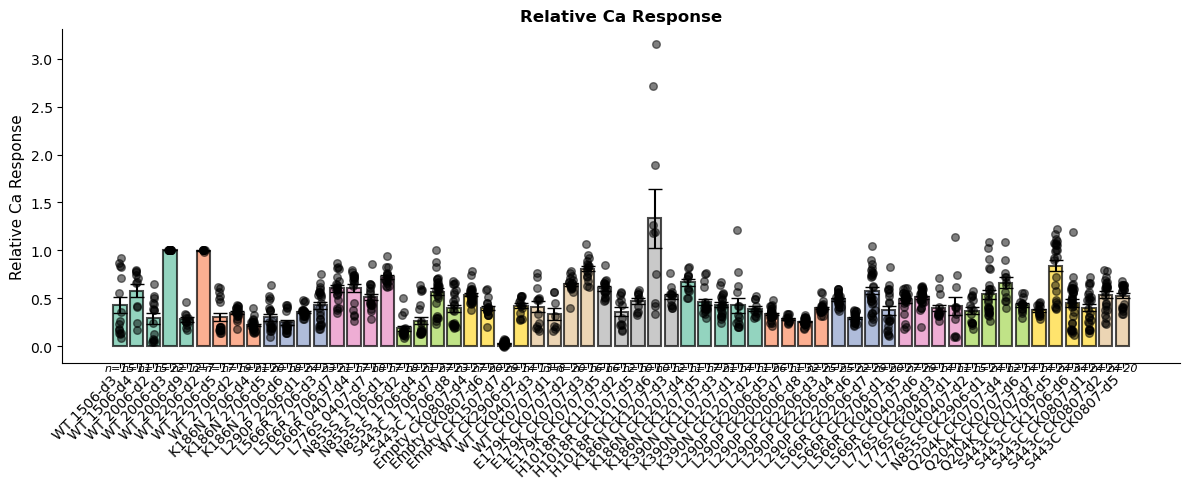

In [29]:
barChart(ca_response_df_individual,"Relative CA response")

# Genotype level analysis

In [30]:
basalc.keys()

dict_keys(['WT 1506-d3', 'WT 1506-d4', 'WT 2006-d2', 'WT 2006-d3', 'WT 2006-d9', 'WT 2206-d2', 'WT 2206-d5', 'WT 2706-d2', 'K186N 2706-d4', 'K186N 2706-d5', 'K186N 2706-d6', 'L290P 2206-d1', 'L566R 2706-d3', 'L566R 2706-d7', 'L566R 0407-d4', 'L776S 0407-d7', 'N855S 1706-d1', 'N855S 1706-d2', 'N855S 1706-d4', 'S443C 1706-d7', 'S443C 1706-d8', 'Empty CK0807-d4', 'Empty CK0807-d6', 'Empty CK1507-d7', 'WT CK2906-d2', 'WT CK0407-d3', 'WT CK0707-d1', 'E179K CK0707-d2', 'E179K CK0707-d3', 'E179K CK0707-d5', 'H1018R CK1107-d2', 'H1018R CK1107-d5', 'H1018R CK1107-d6', 'K186N CK1207-d3', 'K186N CK1207-d4', 'K186N CK1207-d5', 'K390N CK1107-d3', 'K390N CK1207-d1', 'K390N CK1207-d2', 'L290P CK2006-d5', 'L290P CK2006-d7', 'L290P CK2006-d8', 'L290P CK2206-d3', 'L290P CK2206-d4', 'L290P CK2206-d6', 'L566R CK2206-d7', 'L566R CK2706-d1', 'L566R CK0407-d5', 'L566R CK0407-d6', 'L776S CK2906-d3', 'L776S CK0407-d1', 'L776S CK0407-d2', 'N855S CK2906-d1', 'Q204K CK0707-d4', 'Q204K CK0707-d6', 'Q204K CK0707-d7

In [31]:
"""
Exclude experiments where 
max are missing "WT 2006-d3","WT 2206-d2"
several basal or CA > max H1018 CK1107-d6, S443C CK1706-d5
several basal or CA < min 'S443C CK1706-d6'
""" 
exclusions = ["WT 2006-d3","WT 2206-d2", "H1018R CK1107-d6", "S443C CK1706-d5", 'S443C CK1706-d6']

for item in exclusions:
    del basalc[item]
    
basalc_g = compile_genotype_series(basalc)
    
basal_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in basalc_g.items()})


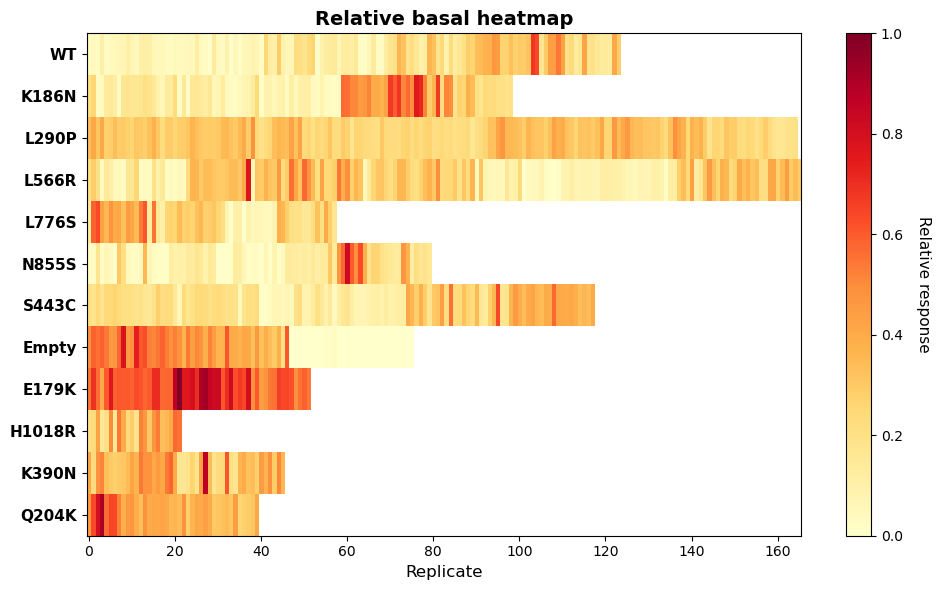

In [32]:
heatmap(basal_df)

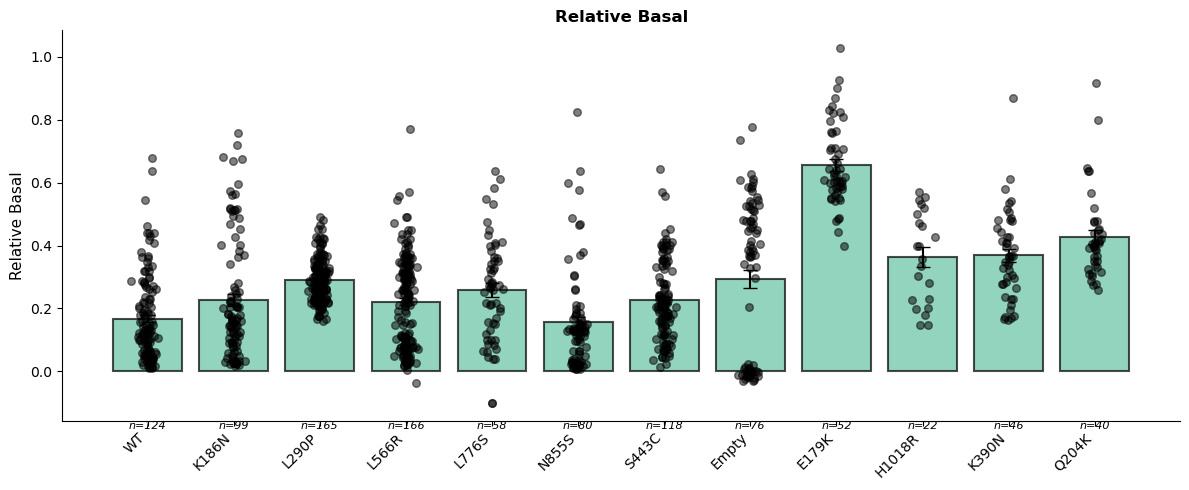

In [33]:
barChart(basal_df)

In [34]:
results = statistical_comparison(basal_df)

In [35]:
print(results)

{'metric': 'delta', 'F_statistic': 50.4636874747582, 'p_value': 9.238841078159613e-89, 'eta_squared': 0.34931745379665435, 'significant': True, 'posthoc': {'WT vs K186N': {'p_value': 0.008009992784511503, 'mean_diff': -0.05979433645794904, 'cohens_d': -0.35572852569025104}, 'WT vs L290P': {'p_value': 3.7364553403592714e-20, 'mean_diff': -0.12349556567158332, 'cohens_d': -1.1312584197074729}, 'WT vs L566R': {'p_value': 0.0016001108063845582, 'mean_diff': -0.05404642525632067, 'cohens_d': -0.38077495556904156}, 'WT vs L776S': {'p_value': 0.00014748289448193497, 'mean_diff': -0.09114924205243086, 'cohens_d': -0.6017175660095615}, 'WT vs N855S': {'p_value': 0.5570023921483289, 'mean_diff': 0.012517866196735061, 'cohens_d': 0.08342316614520413}, 'WT vs S443C': {'p_value': 0.0008064138441114047, 'mean_diff': -0.0577408266129093, 'cohens_d': -0.4388610384134449}, 'WT vs Empty': {'p_value': 1.141255212797493e-05, 'mean_diff': -0.12481830687503065, 'cohens_d': -0.6157716507478954}, 'WT vs E179K

In [36]:
for item in results["posthoc"].keys():
    outcome = results["posthoc"][item]
    if outcome["p_value"]<(0.05/((len(results["posthoc"].keys())))):
        print(item)
        print(outcome)

WT vs L290P
{'p_value': 3.7364553403592714e-20, 'mean_diff': -0.12349556567158332, 'cohens_d': -1.1312584197074729}
WT vs L566R
{'p_value': 0.0016001108063845582, 'mean_diff': -0.05404642525632067, 'cohens_d': -0.38077495556904156}
WT vs L776S
{'p_value': 0.00014748289448193497, 'mean_diff': -0.09114924205243086, 'cohens_d': -0.6017175660095615}
WT vs S443C
{'p_value': 0.0008064138441114047, 'mean_diff': -0.0577408266129093, 'cohens_d': -0.4388610384134449}
WT vs Empty
{'p_value': 1.141255212797493e-05, 'mean_diff': -0.12481830687503065, 'cohens_d': -0.6157716507478954}
WT vs E179K
{'p_value': 3.311348406421344e-51, 'mean_diff': -0.4874582095101113, 'cohens_d': -3.651266531634508}
WT vs H1018R
{'p_value': 1.3126264237112007e-08, 'mean_diff': -0.19523663774548916, 'cohens_d': -1.395382878861305}
WT vs K390N
{'p_value': 2.6488601369833263e-14, 'mean_diff': -0.20083867044621062, 'cohens_d': -1.446151882850498}
WT vs Q204K
{'p_value': 2.1841714271518675e-19, 'mean_diff': -0.260025097784805

## ca

In [37]:
ca_response.keys()

dict_keys(['WT 1506-d3', 'WT 1506-d4', 'WT 2006-d2', 'WT 2006-d3', 'WT 2006-d9', 'WT 2206-d2', 'WT 2206-d5', 'WT 2706-d2', 'K186N 2706-d4', 'K186N 2706-d5', 'K186N 2706-d6', 'L290P 2206-d1', 'L566R 2706-d3', 'L566R 2706-d7', 'L566R 0407-d4', 'L776S 0407-d7', 'N855S 1706-d1', 'N855S 1706-d2', 'N855S 1706-d4', 'S443C 1706-d7', 'S443C 1706-d8', 'Empty CK0807-d4', 'Empty CK0807-d6', 'Empty CK1507-d7', 'WT CK2906-d2', 'WT CK0407-d3', 'WT CK0707-d1', 'E179K CK0707-d2', 'E179K CK0707-d3', 'E179K CK0707-d5', 'H1018R CK1107-d2', 'H1018R CK1107-d5', 'H1018R CK1107-d6', 'K186N CK1207-d3', 'K186N CK1207-d4', 'K186N CK1207-d5', 'K390N CK1107-d3', 'K390N CK1207-d1', 'K390N CK1207-d2', 'L290P CK2006-d5', 'L290P CK2006-d7', 'L290P CK2006-d8', 'L290P CK2206-d3', 'L290P CK2206-d4', 'L290P CK2206-d6', 'L566R CK2206-d7', 'L566R CK2706-d1', 'L566R CK0407-d5', 'L566R CK0407-d6', 'L776S CK2906-d3', 'L776S CK0407-d1', 'L776S CK0407-d2', 'N855S CK2906-d1', 'Q204K CK0707-d4', 'Q204K CK0707-d6', 'Q204K CK0707-d7

In [38]:
for item in exclusions:
    del ca_response[item]
    
ca_response_g = compile_genotype_series(ca_response)
    
ca_response_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in ca_response_g.items()})

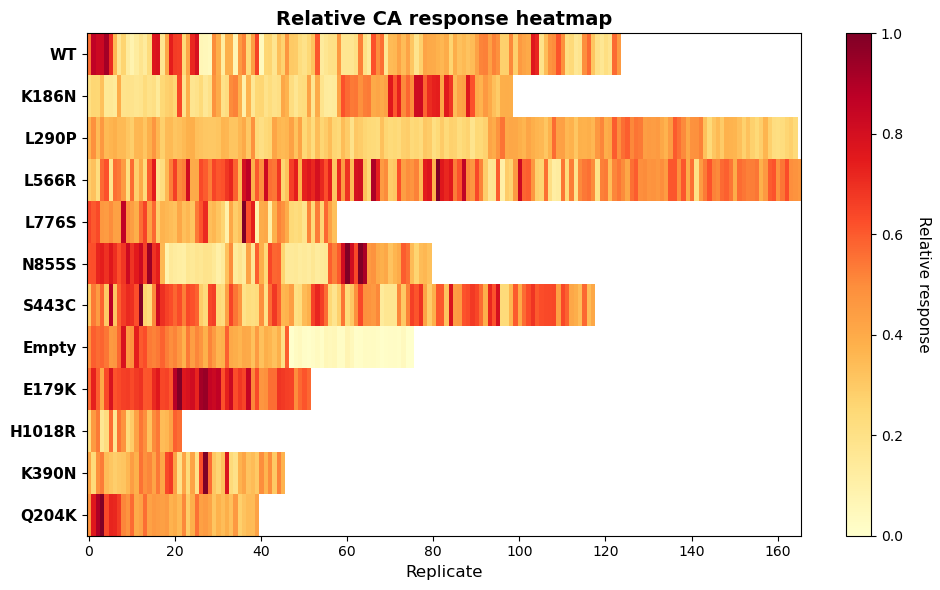

In [39]:
heatmap(ca_response_df, "Relative CA response heatmap")

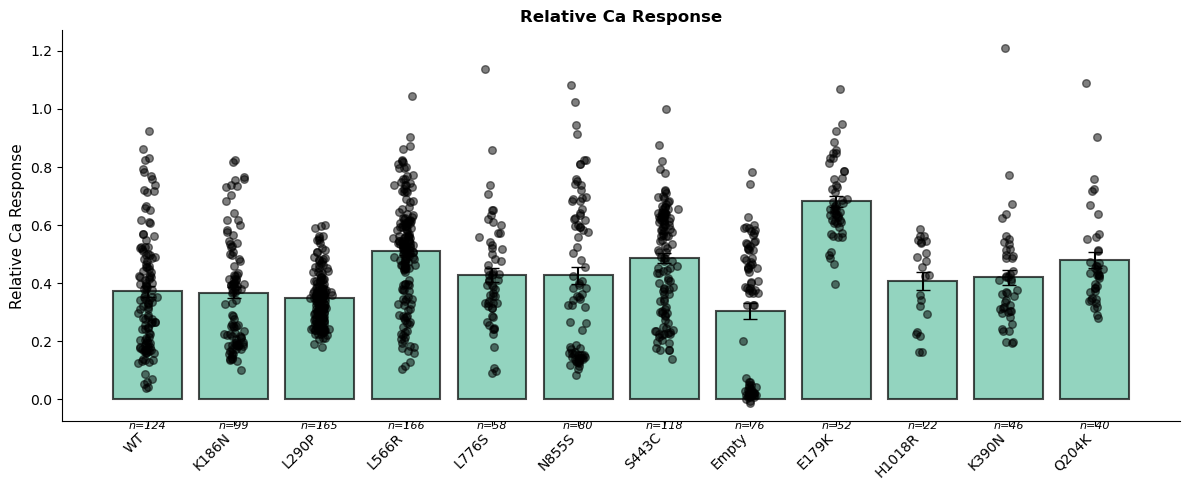

In [40]:
barChart(ca_response_df,"relative ca response")

In [41]:
results = statistical_comparison(ca_response_df)

In [42]:
print(results)

{'metric': 'delta', 'F_statistic': 21.457479938111366, 'p_value': 1.1614669116823325e-39, 'eta_squared': 0.18584746479494615, 'significant': True, 'posthoc': {'WT vs K186N': {'p_value': 0.8715505223660399, 'mean_diff': 0.0042760152189962874, 'cohens_d': 0.021993172198568372}, 'WT vs L290P': {'p_value': 0.1647798641459277, 'mean_diff': 0.02467365224465734, 'cohens_d': 0.15823034600326497}, 'WT vs L566R': {'p_value': 2.934499109872342e-09, 'mean_diff': -0.13769667681192688, 'cohens_d': -0.7239146441458292}, 'WT vs L776S': {'p_value': 0.06758640814626801, 'mean_diff': -0.05742772344266461, 'cohens_d': -0.2987563143333387}, 'WT vs N855S': {'p_value': 0.09576399069642107, 'mean_diff': -0.05494943953742526, 'cohens_d': -0.23401455979806107}, 'WT vs S443C': {'p_value': 6.6277783675520955e-06, 'mean_diff': -0.11431914267932147, 'cohens_d': -0.5956415223909594}, 'WT vs Empty': {'p_value': 0.0335808032111592, 'mean_diff': 0.06732179815450307, 'cohens_d': 0.3070868886741662}, 'WT vs E179K': {'p_v

In [43]:
for item in results["posthoc"].keys():
    outcome = results["posthoc"][item]
    if outcome["p_value"]<(0.05/((len(results["posthoc"].keys())))):
        print(item)
        print(outcome)

WT vs L566R
{'p_value': 2.934499109872342e-09, 'mean_diff': -0.13769667681192688, 'cohens_d': -0.7239146441458292}
WT vs S443C
{'p_value': 6.6277783675520955e-06, 'mean_diff': -0.11431914267932147, 'cohens_d': -0.5956415223909594}
WT vs E179K
{'p_value': 1.6141629831700988e-19, 'mean_diff': -0.30973629442245765, 'cohens_d': -1.8372498453812098}
WT vs Q204K
{'p_value': 0.0027124655485273167, 'mean_diff': -0.10755995643344979, 'cohens_d': -0.5815171924597577}


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Basal and Agonist-Evoked Calcium Responses'}, xlabel='Genotype', ylabel='Normalized Calcium Ratio'>)

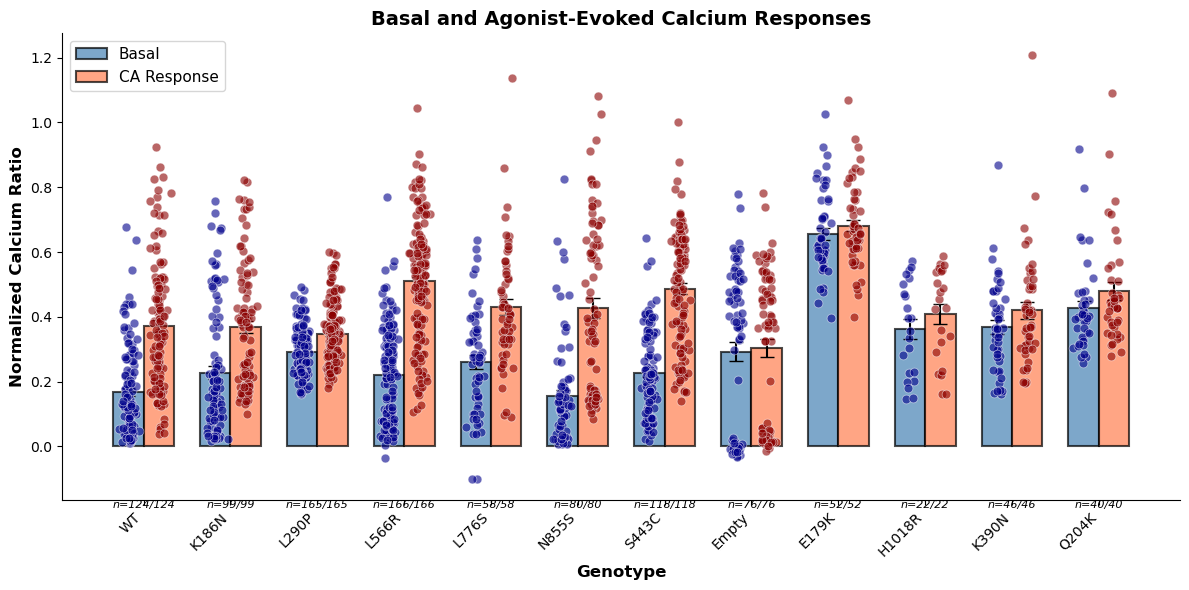

In [44]:
plot_basal_and_response(basal_df, ca_response_df)

# Confirm with unscaled data

In [45]:
# check against unscaled data
basal = {}
ca = {}
for key in traces.keys():
    print(key)
    basal[key] = calculate_relative_basal(traces[key], scale=False)
    ca[key] = calculate_relative_CA_response(traces[key], scale=False)
    
basalc = {}
for key in basal.keys():
    basalc[key] = remove_non_ratio_elements_series(basal[key])

ca_response = {}
for key in ca.keys():
    ca_response[key] = remove_non_ratio_elements_series(ca[key])

WT 1506-d3
WT 1506-d4
WT 2006-d2
WT 2006-d3
WT 2006-d9
WT 2206-d2
Warning- no further treatments after CA
WT 2206-d5
WT 2706-d2
K186N 2706-d4
K186N 2706-d5
K186N 2706-d6
L290P 2206-d1
L566R 2706-d3
L566R 2706-d7
L566R 0407-d4
L776S 0407-d7
N855S 1706-d1
N855S 1706-d2
N855S 1706-d4
S443C 1706-d7
S443C 1706-d8


In [46]:
print("From processed data")
for key in processed.keys():
    print(key)
    basalc[key] = calculate_relative_basal_processed(processed[key], scale=False)
    ca_response[key] = calculate_relative_CA_response_processed(processed[key], scale=False)

for item in exclusions:
    del ca_response[item]
    del basalc[item]
    

From processed data
Empty CK0807-d4
Empty CK0807-d6
Empty CK1507-d7
WT CK2906-d2
WT CK0407-d3
WT CK0707-d1
E179K CK0707-d2
E179K CK0707-d3
E179K CK0707-d5
H1018R CK1107-d2
H1018R CK1107-d5
H1018R CK1107-d6
K186N CK1207-d3
K186N CK1207-d4
K186N CK1207-d5
K390N CK1107-d3
K390N CK1207-d1
K390N CK1207-d2
L290P CK2006-d5
L290P CK2006-d7
L290P CK2006-d8
L290P CK2206-d3
L290P CK2206-d4
L290P CK2206-d6
L566R CK2206-d7
L566R CK2706-d1
L566R CK0407-d5
L566R CK0407-d6
L776S CK2906-d3
L776S CK0407-d1
L776S CK0407-d2
N855S CK2906-d1
Q204K CK0707-d4
Q204K CK0707-d6
Q204K CK0707-d7
S443C CK1706-d5
S443C CK1706-d6
S443C CK0807-d1
S443C CK0807-d2
S443C CK0807-d5


In [47]:
calculate_relative_CA_response_processed(processed["S443C CK0807-d5"],scale=False)

R2 R1     1.043
R3 R1     1.087
R4 R1     1.059
R5 R1     1.077
R6 R1     1.115
R7 R1     1.145
R8 R1     1.133
R9 R1     1.111
R10 R1    1.134
R11 R1    1.112
R12 R1    1.145
R13 R1    1.029
R14 R1    1.095
R15 R1    1.091
R16 R1    1.039
R17 R1    1.035
R18 R1     1.04
R19 R1    1.082
R20 R1    1.053
R21 R1    1.076
Name: R CA, dtype: object

In [48]:
ca_response_g = compile_genotype_series(ca_response)
    
basal_df_individual = pd.DataFrame({k: v.reset_index(drop=True) for k, v in basalc.items()})

ca_response_df_individual = pd.DataFrame({k: v.reset_index(drop=True) for k, v in ca_response.items()})
    
basalc_g = compile_genotype_series(basalc)
    
basal_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in basalc_g.items()})
    
ca_response_g = compile_genotype_series(ca_response)
    
ca_response_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in ca_response_g.items()})

In [49]:
WTkeys = []
for item in basalc.keys():
    if "WT" in item:
        WTkeys.append(item)
for item in WTkeys:
    print("***", item)
    print(basalc[item])

*** WT 1506-d3
R1 R1     0.97775
R2 R1      0.9848
R3 R1     0.99175
R4 R1     1.00465
R5 R1      0.9859
R6 R1      0.9978
R7 R1      0.9931
R8 R1      0.9939
R9 R1      0.9833
R10 R1     0.9946
R11 R1    0.98645
R12 R1     0.9927
R13 R1    1.00145
R14 R1    0.99125
R15 R1    0.99735
dtype: object
*** WT 1506-d4
R1 R1     1.00385
R2 R1       1.029
R3 R1     0.99585
R4 R1      0.9971
R5 R1     0.99505
R6 R1        1.02
R7 R1      1.0387
R8 R1       0.997
R9 R1      0.9959
R10 R1    0.98325
R11 R1    1.00485
dtype: object
*** WT 2006-d2
R1 R1      0.9876
R2 R1      0.9861
R3 R1      0.9827
R4 R1     1.05955
R5 R1     1.03145
R6 R1     0.98045
R7 R1     1.03875
R8 R1     0.96795
R9 R1     0.98815
R10 R1    0.98605
R11 R1     1.0047
R12 R1    0.99735
R13 R1    1.01435
R14 R1    1.01985
R15 R1    0.97615
dtype: object
*** WT 2006-d9
R1 R1     1.02735
R2 R1     1.03055
R3 R1      1.0392
R4 R1     1.07865
R5 R1      1.0299
R6 R1       1.032
R7 R1     1.05245
R8 R1      1.0816
R9 R1     1.0230

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Basal and Agonist-Evoked Calcium Responses'}, xlabel='Genotype', ylabel='Normalized Calcium Ratio'>)

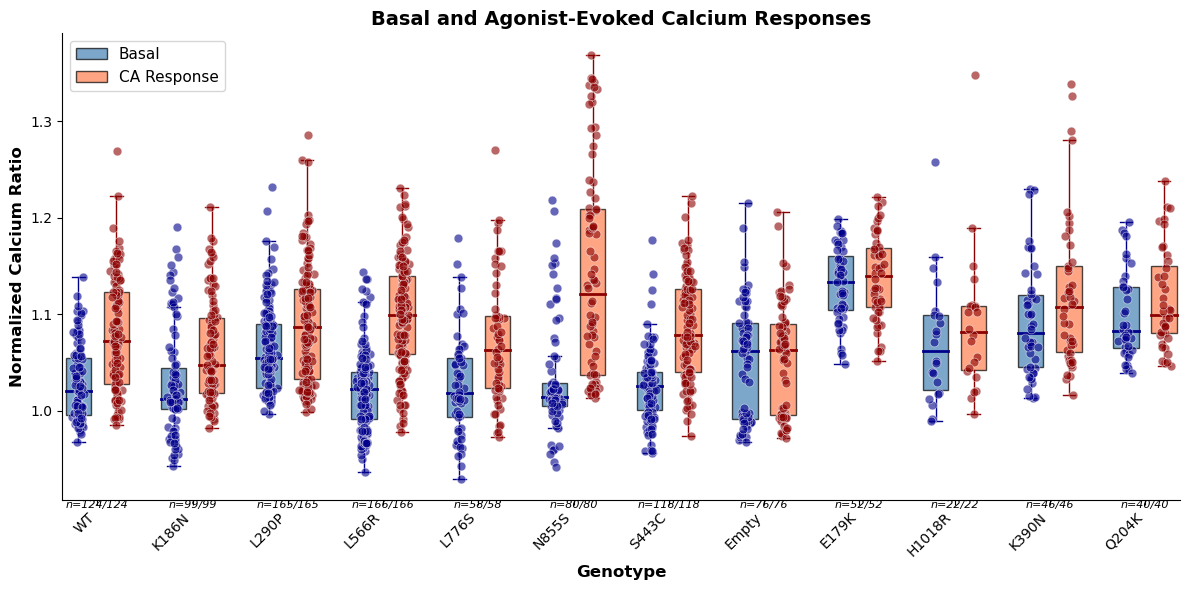

In [50]:
plot_boxplot_basal_response(basal_df, ca_response_df)

In [51]:
results = statistical_comparison(basal_df)
print(results)

{'metric': 'delta', 'F_statistic': 38.199533323429215, 'p_value': 3.284798223596994e-69, 'eta_squared': 0.28895361702959377, 'significant': True, 'posthoc': {'WT vs K186N': {'p_value': 0.8360747181745088, 'mean_diff': -0.0012839659813090876, 'cohens_d': -0.027477799321867977}, 'WT vs L290P': {'p_value': 7.745260478975439e-13, 'mean_diff': -0.03647315938594353, 'cohens_d': -0.9039331271063993}, 'WT vs L566R': {'p_value': 0.17077761700483046, 'mean_diff': 0.006376672920107351, 'cohens_d': 0.16436884944521593}, 'WT vs L776S': {'p_value': 0.9259479193502405, 'mean_diff': 0.0006364738377744317, 'cohens_d': 0.013987746534111608}, 'WT vs N855S': {'p_value': 0.5392399799121153, 'mean_diff': -0.004069383019335682, 'cohens_d': -0.08480376260726244}, 'WT vs S443C': {'p_value': 0.655020875593259, 'mean_diff': 0.0021255515519502666, 'cohens_d': 0.05779683083744239}, 'WT vs Empty': {'p_value': 0.0005021847906879779, 'mean_diff': -0.02416984332296357, 'cohens_d': -0.4911034693096013}, 'WT vs E179K': 

In [52]:
for item in results["posthoc"].keys():
    outcome = results["posthoc"][item]
    if outcome["p_value"]<(0.05/((len(results["posthoc"].keys())))):
        print(item)
        print(outcome)

WT vs L290P
{'p_value': 7.745260478975439e-13, 'mean_diff': -0.03647315938594353, 'cohens_d': -0.9039331271063993}
WT vs Empty
{'p_value': 0.0005021847906879779, 'mean_diff': -0.02416984332296357, 'cohens_d': -0.4911034693096013}
WT vs E179K
{'p_value': 2.40383222054949e-37, 'mean_diff': -0.10343808773939012, 'cohens_d': -2.718780894749137}
WT vs H1018R
{'p_value': 1.471699325237753e-05, 'mean_diff': -0.04412087180424429, 'cohens_d': -0.8542736568942392}
WT vs K390N
{'p_value': 4.575119549896366e-15, 'mean_diff': -0.065259663816438, 'cohens_d': -1.3553684596183593}
WT vs Q204K
{'p_value': 1.880247746496767e-18, 'mean_diff': -0.0711608719899246, 'cohens_d': -1.7396790826817812}


In [53]:
results = statistical_comparison(ca_response_df)
print(results)

{'metric': 'delta', 'F_statistic': 14.48127247214426, 'p_value': 2.6320884580845906e-26, 'eta_squared': 0.13349099012332005, 'significant': True, 'posthoc': {'WT vs K186N': {'p_value': 0.04396659827249613, 'mean_diff': 0.01529643206256126, 'cohens_d': 0.2756581610123215}, 'WT vs L290P': {'p_value': 0.13024679319780902, 'mean_diff': -0.010564173998045101, 'cohens_d': -0.1811590215926887}, 'WT vs L566R': {'p_value': 0.0016913899852103748, 'mean_diff': -0.021035075787019242, 'cohens_d': -0.37561895659490707}, 'WT vs L776S': {'p_value': 0.558208772367164, 'mean_diff': 0.00564543937708617, 'cohens_d': 0.09192143877913993}, 'WT vs N855S': {'p_value': 1.430476721290197e-07, 'mean_diff': -0.06394637096774147, 'cohens_d': -0.7375191976882113}, 'WT vs S443C': {'p_value': 0.25166730151050665, 'mean_diff': -0.008225396391470019, 'cohens_d': -0.14856334169420238}, 'WT vs Empty': {'p_value': 0.004270328777358532, 'mean_diff': 0.024298035172447996, 'cohens_d': 0.4244291777259805}, 'WT vs E179K': {'p_

In [54]:
for item in results["posthoc"].keys():
    outcome = results["posthoc"][item]
    if outcome["p_value"]<(0.05/((len(results["posthoc"].keys())))):
        print(item)
        print(outcome)

WT vs L566R
{'p_value': 0.0016913899852103748, 'mean_diff': -0.021035075787019242, 'cohens_d': -0.37561895659490707}
WT vs N855S
{'p_value': 1.430476721290197e-07, 'mean_diff': -0.06394637096774147, 'cohens_d': -0.7375191976882113}
WT vs Empty
{'p_value': 0.004270328777358532, 'mean_diff': 0.024298035172447996, 'cohens_d': 0.4244291777259805}
WT vs E179K
{'p_value': 1.883102495370632e-10, 'mean_diff': -0.0606377171215875, 'cohens_d': -1.1905228537913413}
WT vs K390N
{'p_value': 0.00020105125811077488, 'mean_diff': -0.041886044880784956, 'cohens_d': -0.6178034984516462}
WT vs Q204K
{'p_value': 0.00029004254275388075, 'mean_diff': -0.03815887096774184, 'cohens_d': -0.6993211350940062}


# Notes and testing code

In [55]:
print(basal['WT 1506-d3'].index)
ignore=[]
for i,c in enumerate(basal['WT 1506-d3'].index):
    if c.split()[-1]!="R1":
        print(i,c)
        ignore.append(c)
print(ignore)
df = basal['WT 1506-d3']
print("#####")
print((pd.concat([df,df])))

Index(['Time (min)', 'R1 W1 Avg', 'R1 W2 Avg', 'R1 R1', 'R2 W1 Avg',
       'R2 W2 Avg', 'R2 R1', 'R3 W1 Avg', 'R3 W2 Avg', 'R3 R1', 'R4 W1 Avg',
       'R4 W2 Avg', 'R4 R1', 'R5 W1 Avg', 'R5 W2 Avg', 'R5 R1', 'R6 W1 Avg',
       'R6 W2 Avg', 'R6 R1', 'R7 W1 Avg', 'R7 W2 Avg', 'R7 R1', 'R8 W1 Avg',
       'R8 W2 Avg', 'R8 R1', 'R9 W1 Avg', 'R9 W2 Avg', 'R9 R1', 'R10 W1 Avg',
       'R10 W2 Avg', 'R10 R1', 'R11 W1 Avg', 'R11 W2 Avg', 'R11 R1',
       'R12 W1 Avg', 'R12 W2 Avg', 'R12 R1', 'R13 W1 Avg', 'R13 W2 Avg',
       'R13 R1', 'R14 W1 Avg', 'R14 W2 Avg', 'R14 R1', 'R15 W1 Avg',
       'R15 W2 Avg', 'R15 R1'],
      dtype='object')
0 Time (min)
1 R1 W1 Avg
2 R1 W2 Avg
4 R2 W1 Avg
5 R2 W2 Avg
7 R3 W1 Avg
8 R3 W2 Avg
10 R4 W1 Avg
11 R4 W2 Avg
13 R5 W1 Avg
14 R5 W2 Avg
16 R6 W1 Avg
17 R6 W2 Avg
19 R7 W1 Avg
20 R7 W2 Avg
22 R8 W1 Avg
23 R8 W2 Avg
25 R9 W1 Avg
26 R9 W2 Avg
28 R10 W1 Avg
29 R10 W2 Avg
31 R11 W1 Avg
32 R11 W2 Avg
34 R12 W1 Avg
35 R12 W2 Avg
37 R13 W1 Avg
38 R13 W2 Avg
40 R

In [56]:
print(get_CA_row(traces["WT 1506-d3"]))
print(traces["WT 1506-d3"].iloc[138])

138
Time (min)         4.801
R1 W1 Avg     CA (100uM)
R1 W2 Avg            NaN
R1 R1                NaN
R2 W1 Avg            NaN
R2 W2 Avg            NaN
R2 R1                NaN
R3 W1 Avg            NaN
R3 W2 Avg            NaN
R3 R1                NaN
R4 W1 Avg            NaN
R4 W2 Avg            NaN
R4 R1                NaN
R5 W1 Avg            NaN
R5 W2 Avg            NaN
R5 R1                NaN
R6 W1 Avg            NaN
R6 W2 Avg            NaN
R6 R1                NaN
R7 W1 Avg            NaN
R7 W2 Avg            NaN
R7 R1                NaN
R8 W1 Avg            NaN
R8 W2 Avg            NaN
R8 R1                NaN
R9 W1 Avg            NaN
R9 W2 Avg            NaN
R9 R1                NaN
R10 W1 Avg           NaN
R10 W2 Avg           NaN
R10 R1               NaN
R11 W1 Avg           NaN
R11 W2 Avg           NaN
R11 R1               NaN
R12 W1 Avg           NaN
R12 W2 Avg           NaN
R12 R1               NaN
R13 W1 Avg           NaN
R13 W2 Avg           NaN
R13 R1               

In [57]:
getTreatments(wt1506_d3)

,Time (min),R1 W1 Avg
138,4.801,CA (100uM)
194,6.631,Basal
265,8.984,A96 (20uM)
543,18.222,IONO + 5 M CA
565,18.925,Basal


In [58]:
getTreatments(wt1506_d4)

,Time (min),R1 W1 Avg
117,3.914,CA
182,6.066,A96
331,11.011,Basal
399,13.251,Ionomycin + CaCl2
400,13.252,Ionomycin + CaCl2
473,15.661,Basal


In [59]:
getTreatments(wt1506_d4).index

Index([117, 182, 331, 399, 400, 473], dtype='int64')

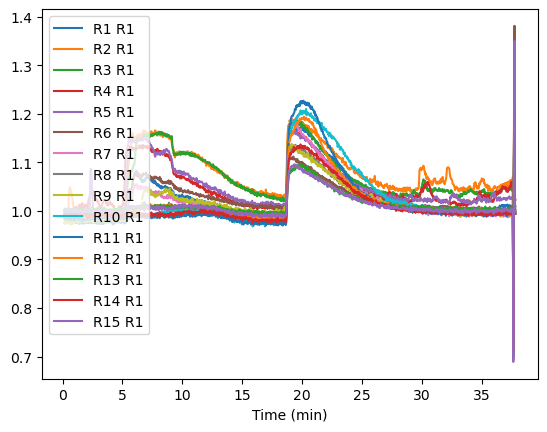

In [60]:
w = getRatioColumns(wt1506_d3)

w.plot(x=w.columns[0])
plt.show()

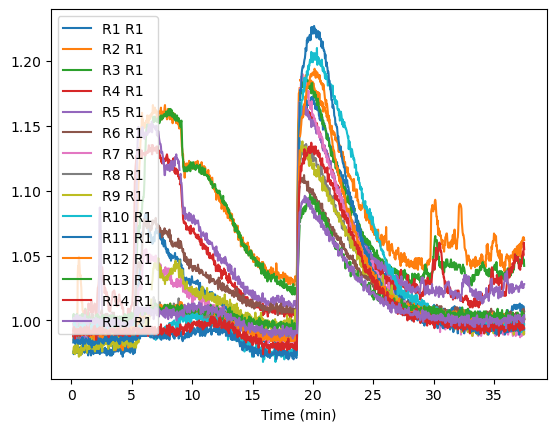

In [61]:
w = remove_flu_columns(traces["WT 1506-d3"])

w.plot(x=w.columns[0])
plt.show()

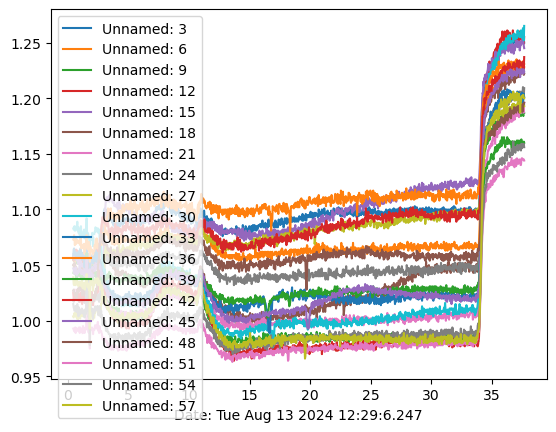

In [62]:
w = remove_flu_columns(traces["WT 2706-d2"]).iloc[20:]

w.plot(x=w.columns[0])
plt.show()

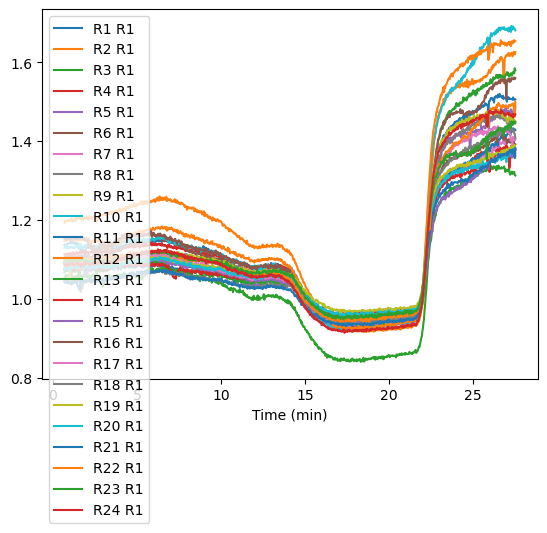

In [63]:
w = remove_flu_columns(traces["L290P 2206-d1"]).iloc[20:]

w.plot(x=w.columns[0])
plt.show()

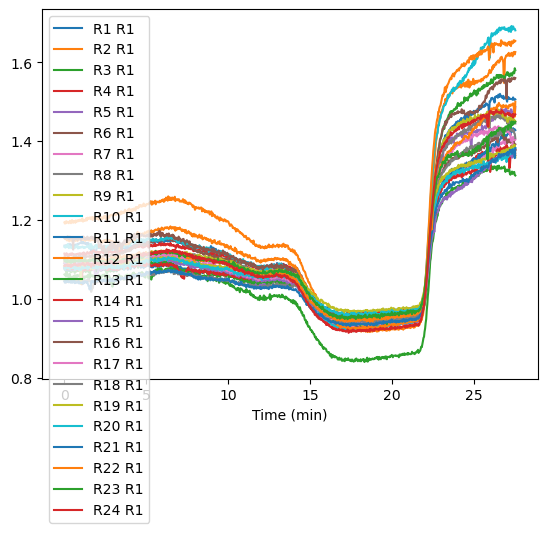

In [64]:
plotTrace(traces,"L290P 2206-d1")

In [65]:
end = traces["WT 2706-d2"].iloc[-10:][traces["WT 2706-d2"].columns[3]]

In [66]:
for i,v in enumerate(end[:-1]):
    print(i,v)
    print(abs(1-v/end.iloc[i+1]))

0 1.253
0.0023885350318472165
1 1.256
0.0
2 1.256
0.002394253790901857
3 1.253
0.0
4 1.253
0.006344171292624878
5 1.261
0.004780876494023811
6 1.255
0.0
7 1.255
0.0015961691939345712
8 1.253
0.0023999999999999577


In [67]:
read_excel_raw("./FG combined data Feb 2025.xlsx",sheet_name="WT 1506-d3") 


Warning- sharp changes at end of file


,Time (min),R1 W1 Avg,R1 W2 Avg,R1 R1,R2 W1 Avg,R2 W2 Avg,R2 R1,R3 W1 Avg,R3 W2 Avg,R3 R1,...,R12 R1,R13 W1 Avg,R13 W2 Avg,R13 R1,R14 W1 Avg,R14 W2 Avg,R14 R1,R15 W1 Avg,R15 W2 Avg,R15 R1
0,0.151,235.955,242.111,0.976,230.438,232.556,0.992,229.371,231.208,0.993,...,0.992,214.425,213.996,1.002,233.706,235.687,0.992,223.290,223.373,1.000
1,0.185,235.551,242.246,0.974,229.431,233.256,0.984,229.844,231.312,0.994,...,0.993,214.932,213.978,1.005,233.761,235.576,0.993,223.658,223.317,1.002
2,0.218,236.097,242.337,0.976,229.785,233.400,0.985,230.423,231.322,0.997,...,0.993,214.662,214.589,1.001,234.451,235.903,0.995,223.291,223.469,1.000
3,0.251,236.209,241.952,0.978,230.579,233.113,0.990,229.831,231.385,0.994,...,0.990,214.582,214.005,1.003,234.214,235.831,0.994,223.333,223.190,1.001
4,0.285,235.683,241.971,0.976,230.088,233.217,0.987,229.715,231.463,0.993,...,0.990,214.338,214.224,1.001,233.461,236.977,0.986,222.926,223.051,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119,37.367,234.529,232.376,1.010,234.656,221.054,1.062,236.547,225.334,1.050,...,0.999,217.463,216.869,1.003,222.728,224.562,0.993,218.096,218.667,0.998
1120,37.400,234.473,232.605,1.009,234.548,220.429,1.064,236.319,226.158,1.045,...,1.001,217.711,216.745,1.005,223.160,224.430,0.995,218.128,217.626,1.003
1121,37.434,234.397,232.097,1.011,234.652,220.833,1.063,236.174,225.737,1.047,...,0.999,217.627,216.704,1.005,223.175,224.233,0.996,218.819,218.485,1.002
1122,37.467,234.527,232.497,1.009,234.444,220.460,1.064,236.510,226.067,1.047,...,1.003,217.343,216.460,1.005,223.045,224.558,0.994,217.883,218.299,0.999


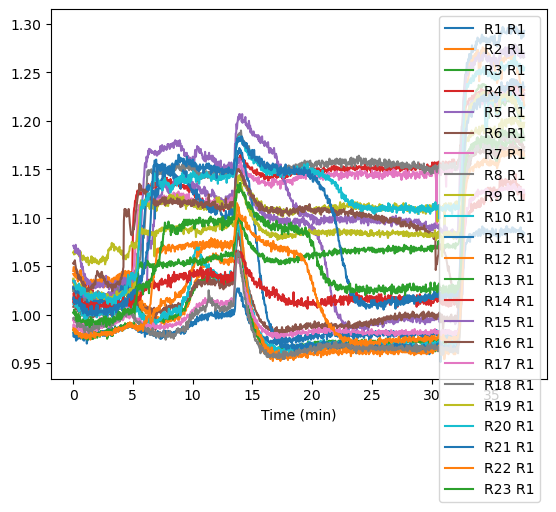

In [68]:
plotTrace(traces,"L566R 2706-d3")

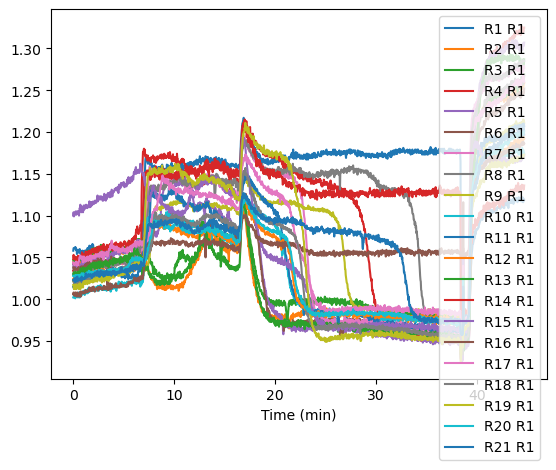

In [69]:
plotTrace(traces,"L566R 2706-d7")

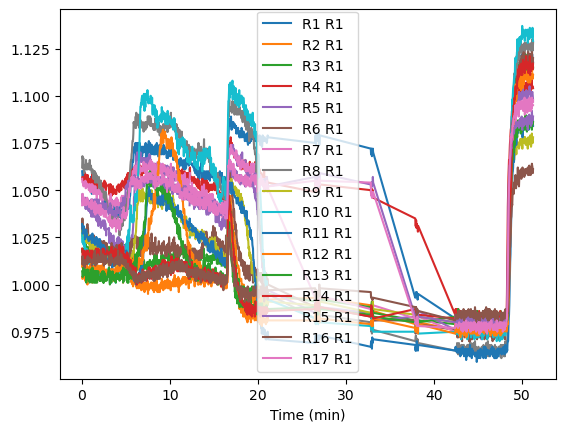

In [70]:
plotTrace(traces,"L566R 0407-d4")